**Nama:** Fepriyadi Harahap  
**Task:** Automatic Speech Recognition (ASR) — CTC fine-tuning  
**Dataset:** [PolyAI/minds14](https://huggingface.co/datasets/PolyAI/minds14)  
**Model:** `facebook/wav2vec2-base-960h`

**Tested Platform:** `Kaggle code`

## 1. Environment Setup

In [1]:
!pip install -q -U "transformers>=4.40" "datasets>=2.18" "accelerate>=0.30" "evaluate"
!pip install -q "librosa" "soundfile" "scikit-learn"
!pip install -q jiwer g2p_en

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 77.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from dataclasses import dataclass
from typing import Dict, List, Union, Optional
import nltk
from jiwer import wer, process_words
from g2p_en import G2p
from IPython.display import Audio as IPyAudio, display

from datasets import load_dataset, Audio
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
    TrainingArguments,
    Trainer,
    pipeline,
    EarlyStoppingCallback
)
import evaluate

nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("cmudict", quiet=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("Using device:", device)

if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    print(f"Visible GPUs: {n_gpu}")
    for i in range(n_gpu):
        props = torch.cuda.get_device_properties(i)
        print(f"  [{i}] {props.name}  |  {props.total_memory/1e9:.1f} GB  |  CC {props.major}.{props.minor}")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark  = True
else:
    n_gpu = 0

Torch: 2.10.0+cu128 | CUDA available: True
Using device: cuda
Visible GPUs: 2
  [0] Tesla T4  |  15.6 GB  |  CC 7.5
  [1] Tesla T4  |  15.6 GB  |  CC 7.5


## 2. Load Dataset

In [3]:
minds = load_dataset("PolyAI/minds14", name="en-US", split="train")
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))

print(minds)
print("\nFirst sample:")
print({k: (v if k != 'audio' else f"<array shape={v['array'].shape}, sr={v['sampling_rate']}>") for k, v in minds[0].items()})

README.md: 0.00B [00:00, ?B/s]

en-US/train-00000-of-00001.parquet:   0%|          | 0.00/34.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/563 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 563
})

First sample:
{'path': 'en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav', 'audio': '<array shape=(173398,), sr=16000>', 'transcription': 'I would like to set up a joint account with my partner', 'english_transcription': 'I would like to set up a joint account with my partner', 'intent_class': 11, 'lang_id': 4}


In [4]:
# Build label mappings
labels = minds.features["intent_class"].names
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for i, l in enumerate(labels)}
num_labels = len(labels)

print(f"Number of intent classes: {num_labels}")
for i, l in id2label.items():
    print(f"  {i:2d} → {l}")

Number of intent classes: 14
   0 → abroad
   1 → address
   2 → app_error
   3 → atm_limit
   4 → balance
   5 → business_loan
   6 → card_issues
   7 → cash_deposit
   8 → direct_debit
   9 → freeze
  10 → high_value_payment
  11 → joint_account
  12 → latest_transactions
  13 → pay_bill


## 3. Exploratory Data Analysis (EDA)

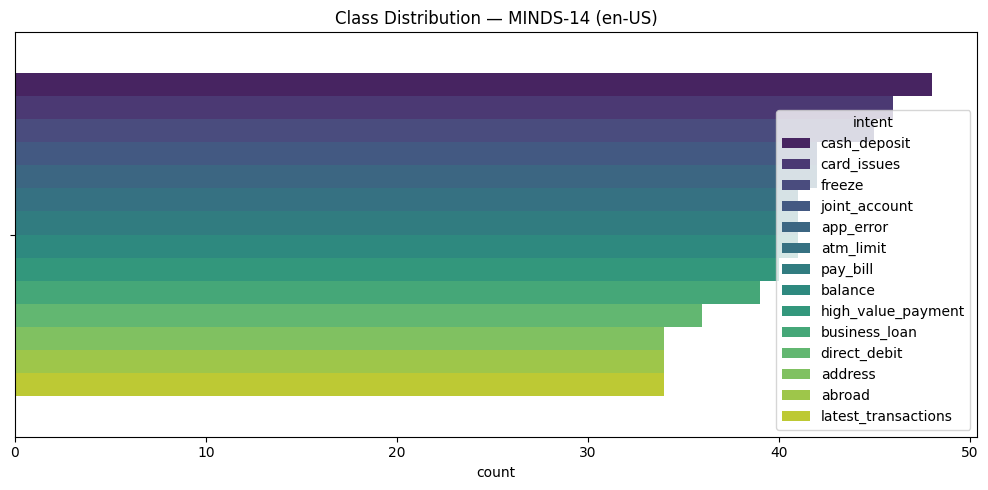

,intent,count
7,cash_deposit,48
6,card_issues,46
9,freeze,45
11,joint_account,42
2,app_error,42
3,atm_limit,41
13,pay_bill,41
4,balance,41
10,high_value_payment,40
5,business_loan,39


In [5]:
# Class Distribution
label_counts = Counter(minds["intent_class"])
df_dist = pd.DataFrame(
    [(id2label[i], c) for i, c in sorted(label_counts.items())],
    columns=["intent", "count"],
).sort_values("count", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_dist, x="count", hue="intent", palette="viridis")
plt.title("Class Distribution — MINDS-14 (en-US)")
plt.tight_layout(); plt.show()
df_dist

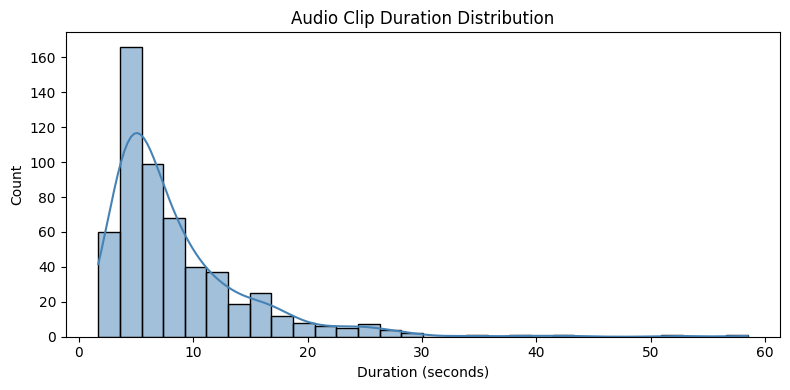

Mean: 8.58s  |  Median: 6.40s  |  Max: 58.45s  |  Min: 1.71s


In [6]:
# Audio duration Distribution

durations = [len(s["array"]) / s["sampling_rate"] for s in minds["audio"]]

plt.figure(figsize=(8, 4))
sns.histplot(durations, bins=30, kde=True, color="steelblue")
plt.xlabel("Duration (seconds)"); plt.ylabel("Count")
plt.title("Audio Clip Duration Distribution")
plt.tight_layout(); plt.show()

print(f"Mean: {np.mean(durations):.2f}s  |  Median: {np.median(durations):.2f}s  |  Max: {np.max(durations):.2f}s  |  Min: {np.min(durations):.2f}s")

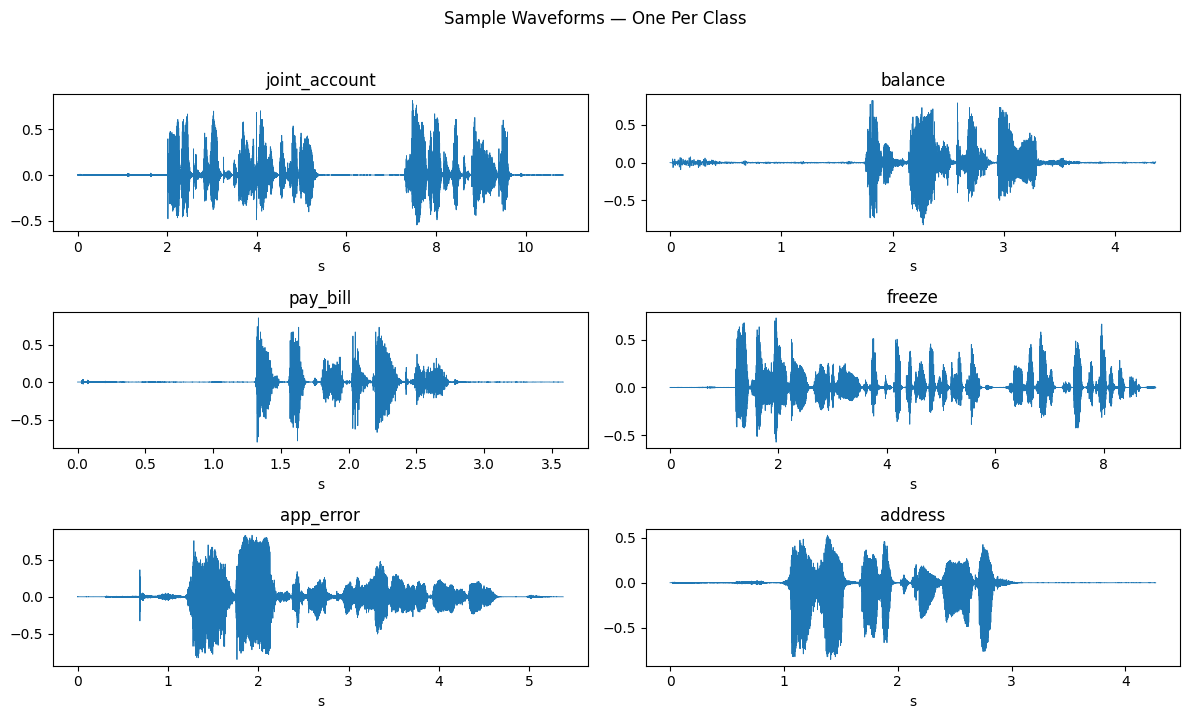

Label: joint_account  |  Transcription: I would like to set up a joint account with my partner


In [ ]:
# Visualize one sample

shown = set()
fig, axes = plt.subplots(3, 2, figsize=(12, 7))
axes = axes.flatten(); idx = 0

for sample in minds:
    cls = sample["intent_class"]
    if cls in shown or idx >= 6:
        continue
    shown.add(cls)
    arr, sr = sample["audio"]["array"], sample["audio"]["sampling_rate"]
    axes[idx].plot(np.linspace(0, len(arr)/sr, len(arr)), arr, linewidth=0.6)
    axes[idx].set_title(f"{id2label[cls]}"); axes[idx].set_xlabel("s")
    idx += 1

plt.suptitle("Sample Waveforms — One Per Class", y=1.02)
plt.tight_layout(); plt.show()

# Play the first sample
s0 = minds[0]
print(f"Label: {id2label[s0['intent_class']]}  |  Transcription: {s0.get('english_transcription', '')}")
display(IPyAudio(s0["audio"]["array"], rate=s0["audio"]["sampling_rate"]))

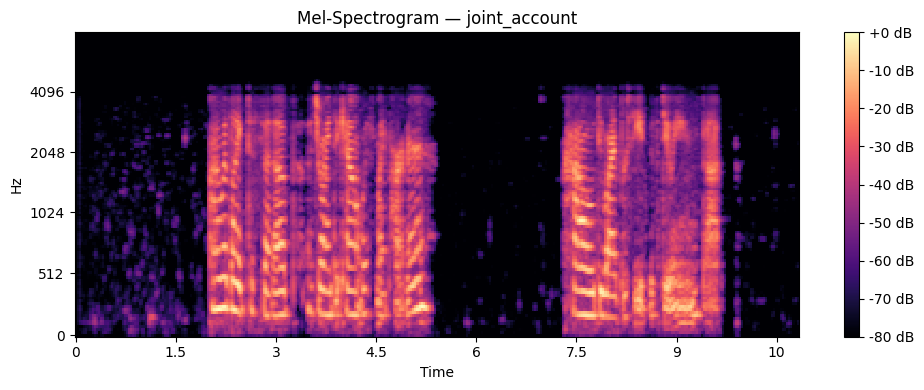

In [8]:
y = minds[0]["audio"]["array"]; sr = minds[0]["audio"]["sampling_rate"]
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis="time", y_axis="mel", fmax=8000)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel-Spectrogram — {id2label[minds[0]['intent_class']]}")
plt.tight_layout(); plt.show()

## 4. Preprocessing & Train/Test Split

In [9]:
minds = minds.remove_columns([c for c in minds.column_names if c not in ("audio", "intent_class", "english_transcription")])

split = minds.train_test_split(test_size=0.2, seed=SEED, stratify_by_column="intent_class")
train_ds, test_ds = split["train"], split["test"]
print(f"Train: {len(train_ds)}  |  Test: {len(test_ds)}")

Train: 450  |  Test: 113


In [10]:
MODEL_CHECKPOINT = "facebook/wav2vec2-large-960h-lv60-self"
MAX_DURATION_S   = 8.0

processor = Wav2Vec2Processor.from_pretrained(MODEL_CHECKPOINT)
feature_extractor = processor.feature_extractor
MAX_LEN = int(feature_extractor.sampling_rate * MAX_DURATION_S)

def normalize_text(t: str) -> str:
    t = t.upper()
    t = re.sub(r"[^A-Z' ]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def preprocess(batch):
    arr = np.asarray(batch["audio"]["array"], dtype=np.float32)[:MAX_LEN]
    batch["input_values"] = processor(arr, sampling_rate=16_000).input_values[0]
    batch["input_length"] = len(batch["input_values"])
    batch["labels"] = processor.tokenizer(normalize_text(batch["english_transcription"])).input_ids
    return batch

train_enc = train_ds.map(preprocess, remove_columns=train_ds.column_names)
test_enc  = test_ds.map(preprocess,  remove_columns=test_ds.column_names)
print(train_enc)
print(f"Vocab size: {len(processor.tokenizer)}  |  pad_id: {processor.tokenizer.pad_token_id}")

preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/162 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

Dataset({
    features: ['input_values', 'input_length', 'labels'],
    num_rows: 450
})
Vocab size: 32  |  pad_id: 0


## 5. Model — Wav2Vec2 CTC Fine-Tuning

In [11]:
model = Wav2Vec2ForCTC.from_pretrained(
    MODEL_CHECKPOINT,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
)

model.config.mask_time_prob = 0.075
model.config.mask_time_length = 10
model.config.mask_feature_prob = 0.05
model.config.mask_feature_length = 64
model.config.hidden_dropout = 0.15
model.config.attention_dropout = 0.15
model.config.feat_proj_dropout = 0.1
model.config.layerdrop = 0.05

model.freeze_feature_encoder()

NUM_UNFROZEN_LAYERS = 6
encoder_layers = model.wav2vec2.encoder.layers
num_layers = len(encoder_layers)
freeze_upto = num_layers - NUM_UNFROZEN_LAYERS

for p in model.wav2vec2.feature_projection.parameters():
    p.requires_grad = False
for p in model.wav2vec2.encoder.pos_conv_embed.parameters():
    p.requires_grad = False
if getattr(model.wav2vec2.encoder, "layer_norm", None) is not None:
    for p in model.wav2vec2.encoder.layer_norm.parameters():
        p.requires_grad = False
for layer in encoder_layers[:freeze_upto]:
    for p in layer.parameters():
        p.requires_grad = False

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen transformer layers: 0..{freeze_upto - 1}  |  Trainable: {freeze_upto}..{num_layers - 1} + lm_head")
print(f"Total params:     {n_total:,}")
print(f"Trainable params: {n_trainable:,}  ({100*n_trainable/n_total:.1f}%)")
print(f"Vocab size            : {len(processor.tokenizer)}")
print(f"PAD token / id        : {processor.tokenizer.pad_token!r} / {processor.tokenizer.pad_token_id}")
print(f"UNK token / id        : {processor.tokenizer.unk_token!r} / {processor.tokenizer.unk_token_id}")
print(f"Word-delimiter token  : {processor.tokenizer.word_delimiter_token!r}")

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h-lv60-self
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen transformer layers: 0..17  |  Trainable: 18..23 + lm_head
Total params:     315,471,520
Trainable params: 75,611,168  (24.0%)
Vocab size            : 32
PAD token / id        : '<pad>' / 0
UNK token / id        : '<unk>' / 3
Word-delimiter token  : '|'


In [12]:
@dataclass
class DataCollatorCTCWithPadding:
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            max_length=self.max_length_labels,
            pad_to_multiple_of=self.pad_to_multiple_of_labels,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        batch["labels"] = labels

        return batch

data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

_g2p = G2p()
def _to_phonemes(t: str) -> str:
    return " ".join([x for x in _g2p(t.lower()) if re.match(r"^[A-Z]+[0-9]?$", x)])

def compute_metrics(pred):
    pred_logits = pred.predictions
    if isinstance(pred_logits, (tuple, list)):
        pred_logits = pred_logits[0]
    pred_ids = np.argmax(pred_logits, axis=-1)

    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str  = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(label_ids, group_tokens=False)

    pairs = [(r.strip(), p.strip()) for r, p in zip(label_str, pred_str) if r.strip()]
    if not pairs:
        return {"wer": 1.0, "per": 1.0}
    refs, hyps = map(list, zip(*pairs))
    return {
        "wer": wer(refs, hyps),
        "per": wer([_to_phonemes(r) for r in refs], [_to_phonemes(h) for h in hyps]),
    }

In [13]:
PER_DEVICE_BS = 32 if n_gpu >= 1 else 4
GRAD_ACCUM    = 1  if n_gpu >= 2 else 2

training_args = TrainingArguments(
    output_dir="./wav2vec2-asr-minds14",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_steps=500,
    eval_steps=500,
    learning_rate=2e-4,
    per_device_train_batch_size=PER_DEVICE_BS,
    per_device_eval_batch_size=PER_DEVICE_BS,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=True, 
    num_train_epochs=30,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    dataloader_pin_memory=torch.cuda.is_available(),
    seed=SEED,
)

print(f"GPUs visible to Trainer : {n_gpu}")
print(f"Per-device train BS     : {PER_DEVICE_BS}")
print(f"Grad accum steps        : {GRAD_ACCUM}")
print(f"Effective global batch  : {PER_DEVICE_BS * max(n_gpu, 1) * GRAD_ACCUM}")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_enc,
    eval_dataset=test_enc,
    data_collator=data_collator,
    processing_class=processor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

GPUs visible to Trainer : 2
Per-device train BS     : 32
Grad accum steps        : 1
Effective global batch  : 64


In [14]:
# Train
train_result = trainer.train()
trainer.save_model("./wav2vec2-asr-minds14/best")
processor.save_pretrained("./wav2vec2-asr-minds14/best")
print(train_result.metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Wer,Per
1,No log,4.841109,0.372107,0.302081
2,19.000793,4.402047,0.376370,0.300394
3,19.190862,3.853113,0.397077,0.310332
4,14.501355,8.632927,0.493910,0.340709


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 333.7617, 'train_samples_per_second': 40.448, 'train_steps_per_second': 0.719, 'total_flos': 4.36107829248e+17, 'train_loss': 17.64353597164154, 'epoch': 4.0}


## 6. Evaluation

In [15]:
eval_metrics = trainer.evaluate()
print("Test metrics:")
for k, v in eval_metrics.items():
    if isinstance(v, float):
        if k.endswith(("_wer", "_per")):
            print(f"  {k}: {v*100:.2f}%")
        else:
            print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Wer,Per
14.501355,4.841109,4,0.372107,0.302081


Test metrics:
  eval_loss: 4.8411
  eval_wer: 37.21%
  eval_per: 30.21%


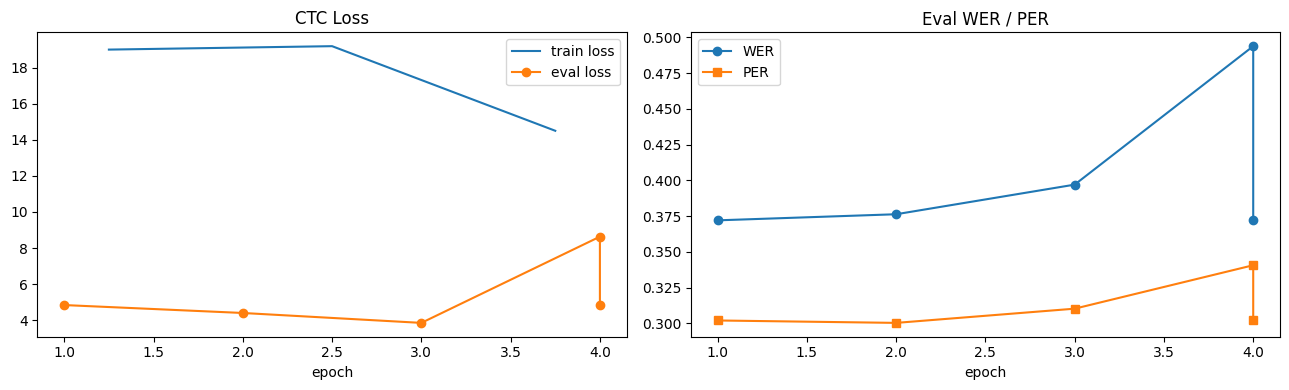

In [16]:
# Training-curve plot
logs = pd.DataFrame(trainer.state.log_history)
train_loss = logs.dropna(subset=["loss"])[["epoch", "loss"]]
eval_log   = logs.dropna(subset=["eval_wer"])[["epoch", "eval_loss", "eval_wer", "eval_per"]]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(train_loss["epoch"], train_loss["loss"], label="train loss")
ax[0].plot(eval_log["epoch"], eval_log["eval_loss"], label="eval loss", marker="o")
ax[0].set_title("CTC Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(eval_log["epoch"], eval_log["eval_wer"], marker="o", label="WER")
ax[1].plot(eval_log["epoch"], eval_log["eval_per"], marker="s", label="PER")
ax[1].set_title("Eval WER / PER"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

In [17]:
# Decode predictions on the test set with the trained model and report final WER/PER + samples
preds_out = trainer.predict(test_enc)
logits = preds_out.predictions
if isinstance(logits, (tuple, list)):
    logits = logits[0]

pred_ids  = np.argmax(logits, axis=-1)
label_ids = preds_out.label_ids
label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

pred_str  = processor.batch_decode(pred_ids)
label_str = processor.batch_decode(label_ids, group_tokens=False)

pairs = [(r.strip(), p.strip()) for r, p in zip(label_str, pred_str) if r.strip()]
ref_words, hyp_words = map(list, zip(*pairs))

m = process_words(ref_words, hyp_words)
print(f"WER: {m.wer*100:.2f}%  (sub={m.substitutions} del={m.deletions} ins={m.insertions} hits={m.hits})")

ref_ph = [_to_phonemes(r) for r in ref_words]
hyp_ph = [_to_phonemes(h) for h in hyp_words]
phoneme_error_rate = wer(ref_ph, hyp_ph)
print(f"PER: {phoneme_error_rate*100:.2f}%")

print("\nPredicted vs Target Transcripts (10 random test samples)")
print("=" * 88)
for i in random.sample(range(len(ref_words)), k=min(10, len(ref_words))):
    s_wer = wer([ref_words[i]], [hyp_words[i]])
    print(f"\n[#{i:>3}]  sample WER = {s_wer*100:5.1f}%")
    print(f"  TARGET   : {ref_words[i]}")
    print(f"  PREDICTED: {hyp_words[i]}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


WER: 37.21%  (sub=188 del=279 ins=144 hits=1175)
PER: 30.21%

Predicted vs Target Transcripts (10 random test samples)

[# 81]  sample WER =   0.0%
  TARGET   : I NEED TO CHANGE MY ADDRESS
  PREDICTED: I NEED TO CHANGE MY ADDRESS

[# 14]  sample WER =   0.0%
  TARGET   : HOW CAN I DEPOSIT MONEY INTO MY ACCOUNT
  PREDICTED: HOW CAN I DEPOSIT MONEY INTO MY ACCOUNT

[#  3]  sample WER = 140.0%
  TARGET   : I'M TRYING TO USE THE INFORMATION IN AN ERROR MESSAGE
  PREDICTED: I'M TRYING TO USE THE AP AND THE P WELL NOT LOAD MY ACOUNT INFORMATION ITS CUTE GIVE ME AN AERO MESSAGE

[# 94]  sample WER =  15.8%
  TARGET   : HOW DO I GO ABOUT SETTING UP A JOINT ACCOUNT WITH MY PARTNER AND HE'S AVAILABLE ON THE APP
  PREDICTED: HOW DO I GO ABOUT SETTING UP A JOINT ACCOUNT WITH MY PARTNER AND IS IS AVAILABLE ON THE T

[# 35]  sample WER =  35.7%
  TARGET   : I'M MAKING A LARGE PAYMENT ON MY ACCOUNT WHAT DO I DO WITH IT
  PREDICTED: I'M MAKING A LARGE PAYMENT ON MY ACCOUNT WHAT DO I DO WITH THE ISEMIS

## 7. Inference

In [18]:
asr = pipeline(
    "automatic-speech-recognition",
    model="./wav2vec2-asr-minds14/best",
    device=0 if torch.cuda.is_available() else -1,
)

# Pull 3 random samples from the test split and transcribe
for idx in random.sample(range(len(test_ds)), 3):
    sample = test_ds[idx]
    audio_arr = np.asarray(sample["audio"]["array"], dtype=np.float32)
    target = sample["english_transcription"]
    out = asr(audio_arr)
    print(f"\nTARGET   : {target}")
    print(f"PREDICTED: {out['text']}")
    display(IPyAudio(audio_arr, rate=16_000))

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]


TARGET   : how do I go about setting up a joint account with my partner and he's available on the app
PREDICTED: HOW DO I GO ABOUT SETTING UP A JOINT ACCOUNT WITH MY PARTNER AND IS IS AVAILABLE ON THE T



TARGET   : work is sending me overseas you are I was wondering make sure my card will work overseas
PREDICTED: I WORK IS SENDING ME OVER SEAS TO EUROPE I WAS WONDERING TO MAKE SURE MY CARD WILL WORK OVERSEAS CAN I PAY ANYTHING AND USE IT WITHOUT ANY PROBLEMS THERE



TARGET   : I would like to withdraw money from an ATM and I'm wondering what the maximum amount of money I can withdraw at one time is
PREDICTED: I WOULD LIKE TO WITHDRAW MONEY FROM AN E T M AND I AM WONDERING WHAT THE MAXIMUM AMOUNT OF MONEY I CAN WITHDRAW AT ONE TIME IS
